# Inference

In [2]:
import pickle
from pathlib import Path

In [3]:
FOLDER       = Path("processed") 
RESULTS      = Path("results") 
GENESET_PATH = None  
SELECT_K     = None   
RESULTS.mkdir(exist_ok=True)

In [4]:
d = pickle.load(open(FOLDER / "cancer_vs_normal.pkl", "rb"))

In [5]:
def subset_genes(available, geneset_path):
    if geneset_path is None:
        return list(available)
    requested = [ln.strip() for ln in open(geneset_path)
                 if ln.strip() and not ln.startswith("#")]
    avail = set(available)
    keep = [g for g in requested if g in avail]
    print(f"  gene set: {len(keep)}/{len(requested)} requested genes found")
    return keep

keep = subset_genes(d["genes"], GENESET_PATH)
print("Used genes:", len(keep))

Used genes: 42536


In [6]:
X    = d["X"][keep].values
y    = d["y"].values.astype(int)

In [7]:
# load
with open("results/taskA_fitted_models.pkl", "rb") as f:
    fitted_models = pickle.load(f)

In [72]:
# or load
with open("results/taskB_fitted_models.pkl", "rb") as f:
    fitted_models = pickle.load(f)

/Users/qiyang/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/qiyang/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


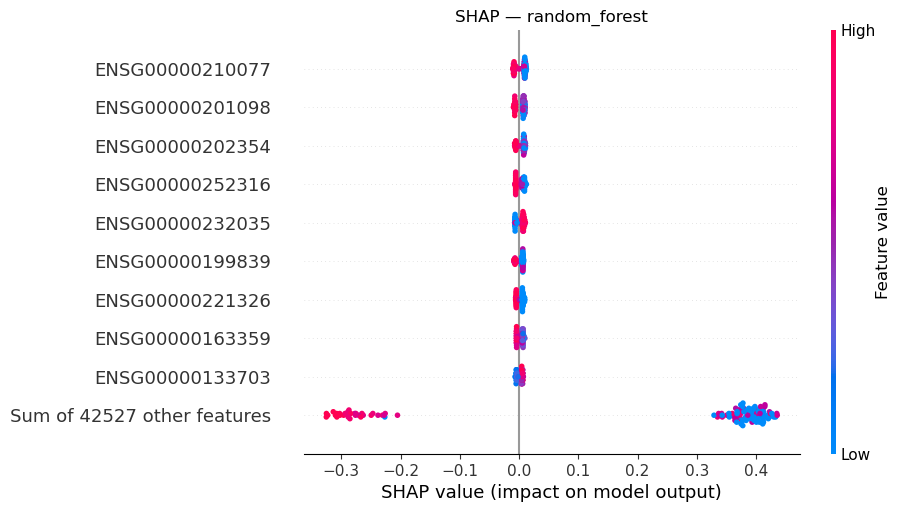

/Users/qiyang/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


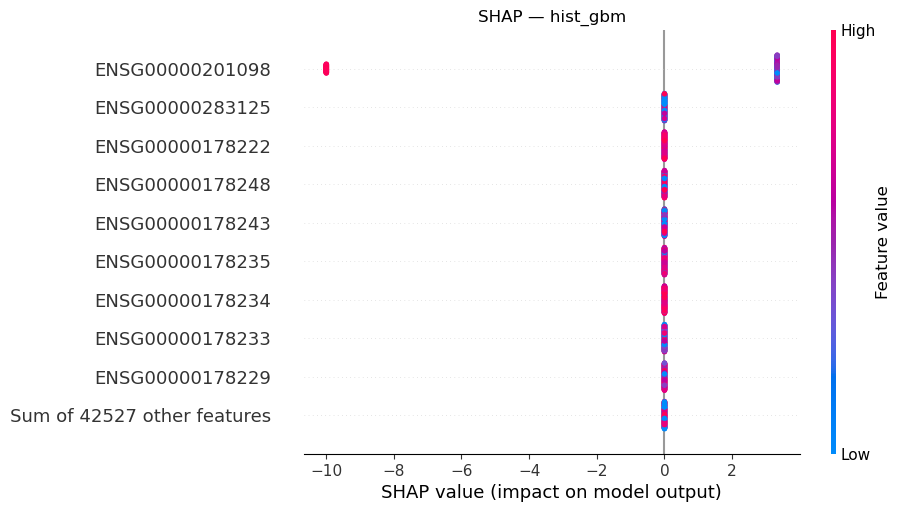

In [8]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

gene_names = d["X"][keep].columns

importance_df = pd.DataFrame(index=gene_names)

# Logistic regression coefficients
for name in ["logreg_l1", "logreg_l2", "logreg_elasticnet"]:
    coef = fitted_models[name].named_steps["clf"].coef_[0]
    importance_df[name] = pd.Series(coef, index=gene_names)

# Tree model SHAP values
for name in ["random_forest", "hist_gbm"]:
    clf = fitted_models[name].named_steps["clf"]

    X_scaled = fitted_models[name].named_steps["scale"].transform(d["X"][keep])
    X_scaled_df = pd.DataFrame(X_scaled, columns=gene_names)

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer(X_scaled_df)

    vals = shap_values.values

    # the two modles have different dimensions. Handel seperately
    if vals.ndim == 3:
        vals = vals[:, :, 1]

    mean_abs_shap = np.abs(vals).mean(axis=0)
    importance_df[name] = pd.Series(mean_abs_shap, index=gene_names)

    plt.figure()
    shap_vals_to_plot = shap_values[:, :, 1] if shap_values.values.ndim == 3 else shap_values
    shap.plots.beeswarm(shap_vals_to_plot, max_display=10, show=False)
    plt.title(f'SHAP — {name}')
    plt.show()

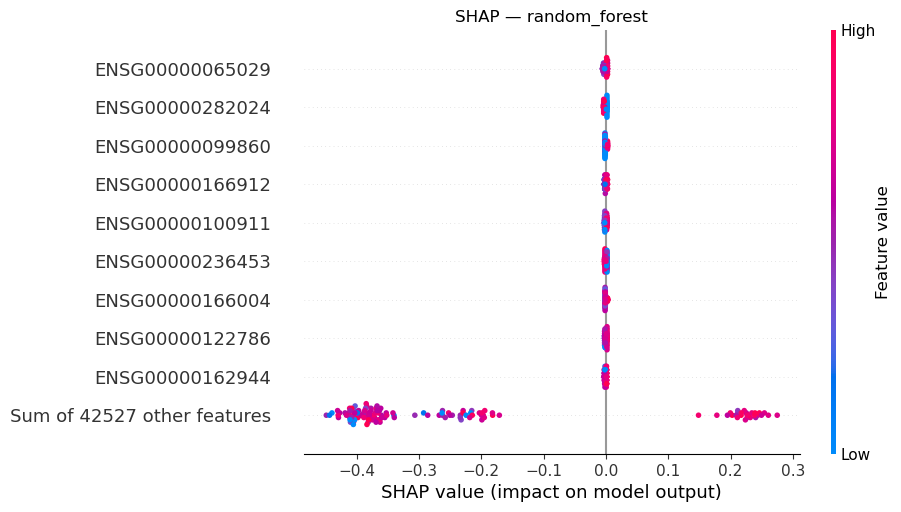

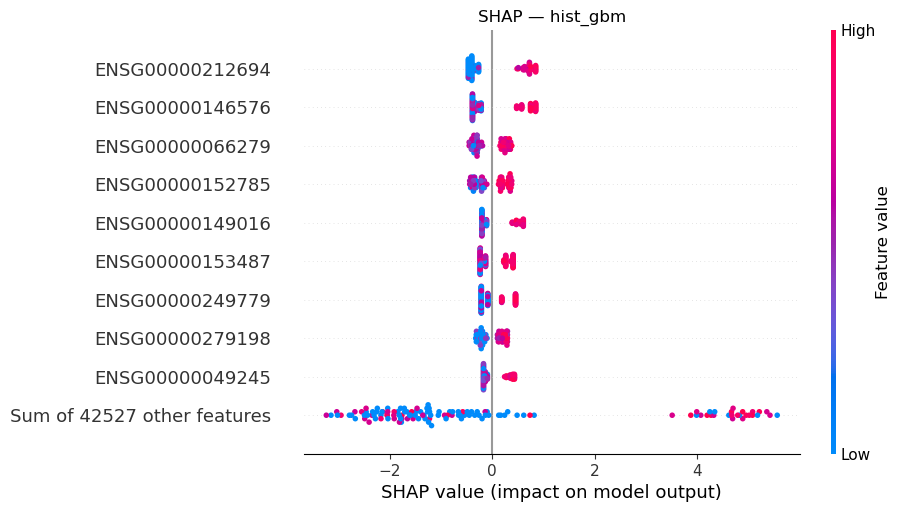

In [73]:
gene_names = d["X"][keep].columns

importance_df = pd.DataFrame(index=gene_names)

# Logistic regression coefficients
for name in ["logreg_l1", "logreg_l2", "logreg_elasticnet"]:
    coef = fitted_models[name].named_steps["clf"].coef_[0]
    importance_df[name] = pd.Series(coef, index=gene_names)

# Tree model SHAP values
for name in ["random_forest", "hist_gbm"]:
    clf = fitted_models[name].named_steps["clf"]

    X_scaled = fitted_models[name].named_steps["scale"].transform(d["X"][keep])
    X_scaled_df = pd.DataFrame(X_scaled, columns=gene_names)

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer(X_scaled_df)

    vals = shap_values.values

    # For binary classification, random forest may return:
    # n_cells x n_features x n_classes
    if vals.ndim == 3:
        vals = vals[:, :, 1]

    mean_abs_shap = np.abs(vals).mean(axis=0)
    importance_df[name] = pd.Series(mean_abs_shap, index=gene_names)

    plt.figure()
    shap_vals_to_plot = shap_values[:, :, 1] if shap_values.values.ndim == 3 else shap_values
    shap.plots.beeswarm(shap_vals_to_plot, max_display=10, show=False)
    plt.title(f'SHAP — {name}')
    plt.show()

In [9]:
top20_features = {}

for col in importance_df.columns:
    top20_features[col] = set(
        importance_df[col]
        .abs()
        .sort_values(ascending=False)
        .head(20)
        .index
    )

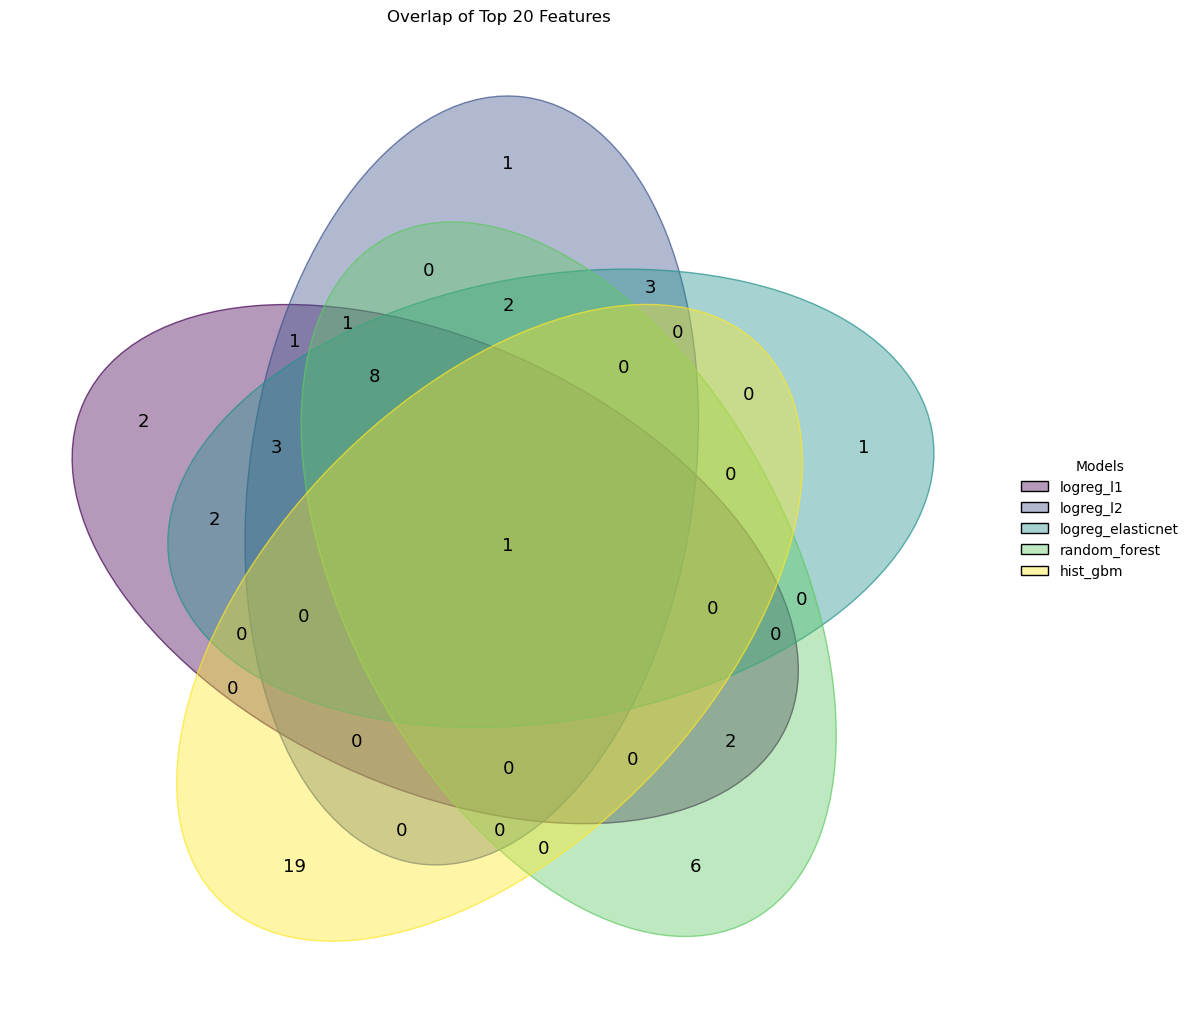

In [14]:
from venn import venn
from matplotlib.patches import Patch
display_names = {
    'logreg_l1_weights': 'LogReg L1',
    'logreg_l2_weights': 'LogReg L2',
    'logreg_elasticnet_weights': 'Elastic Net',
    'random_forest_shap_df': 'Random Forest SHAP',
    'hist_gbm_shap_df': 'HistGBM SHAP'
}


fig, ax = plt.subplots(figsize=(12, 12))

venn_plot = venn(
    top20_features,
    ax=ax
)

plt.title("Overlap of Top 20 Features")

# change color only for visualization purpose. Here I looked up code online.
colors = []
for patch in venn_plot.patches:
    if patch is not None:
        colors.append(patch.get_facecolor())
unique_colors = []
for c in colors:
    if c not in unique_colors:
        unique_colors.append(c)
legend_handles = [
    Patch(facecolor=unique_colors[i],
          edgecolor='black',
          label=label)
    for i, label in enumerate(top20_features.keys())
]

ax.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    title="Models"
)

plt.tight_layout()
plt.show()

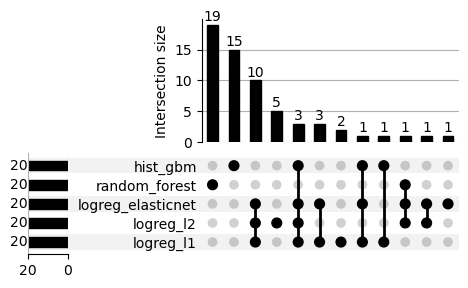

In [99]:
from upsetplot import from_contents, UpSet

def plot_top_feature_overlap(feature_sets):
    upset_data = from_contents(feature_sets)

    fig = plt.figure(figsize=(10, 10))
    UpSet(upset_data,show_counts=True,sort_by="cardinality", element_size=20).plot(fig=fig)

    #plt.suptitle("                  Overlap of top 20 features across 5 models, task B")
    plt.tight_layout()
    plt.show()
plot_top_feature_overlap(top20_features)

"""

\begin{figure}[h]
    \centering
    \includegraphics[width=1\linewidth]{upsetplot.png}
    \caption{\textbf{Overlap of top 20 genes among various models}. The upset plot shows that logistic regression models largely agree (10/20 shared), while the random forest and hgb model operates independently.}
    \label{fig:placeholder}
\end{figure}
"""

In [59]:
val = pickle.load(open(FOLDER / "validation.pkl", "rb"))

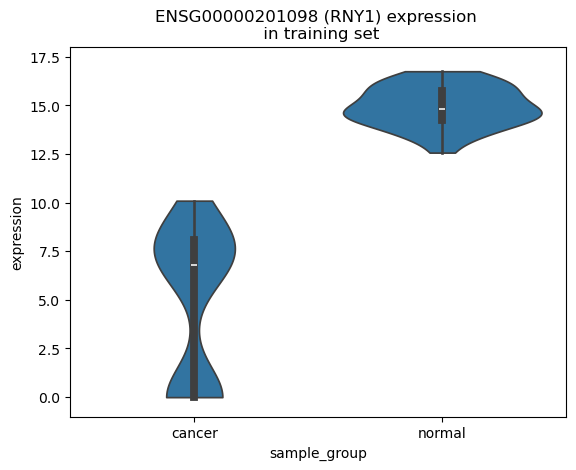

In [57]:
# label 1 is cancer (n = 96)

gene = 'ENSG00000201098'

plot_df = pd.DataFrame({
    'expression': d['X'][gene].values,
    'label': pd.Series(y).map({0: 'normal', 1: 'cancer'})
})

sns.violinplot(data=plot_df, x='label', y='expression', cut = 0)
plt.title(gene + ' (RNY1) expression \n in training set')
plt.ylim(-1, 18)
plt.xlabel('sample_group')
plt.show()

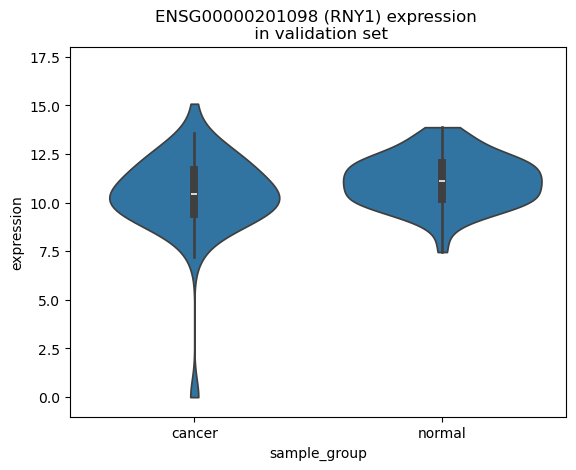

In [60]:
gene = 'ENSG00000201098'

plot_df = pd.DataFrame({
    'expression': val['X'][gene].values,
    'label': pd.Series(val['y_cancer'].values).map({0: 'normal', 1: 'cancer'})
})

sns.violinplot(data=plot_df, x='label', y='expression', cut = 0, order = ['cancer', 'normal'])
plt.ylim(-1, 18)
plt.title(gene + ' (RNY1) expression \n in validation set')
plt.xlabel('sample_group')
plt.show()

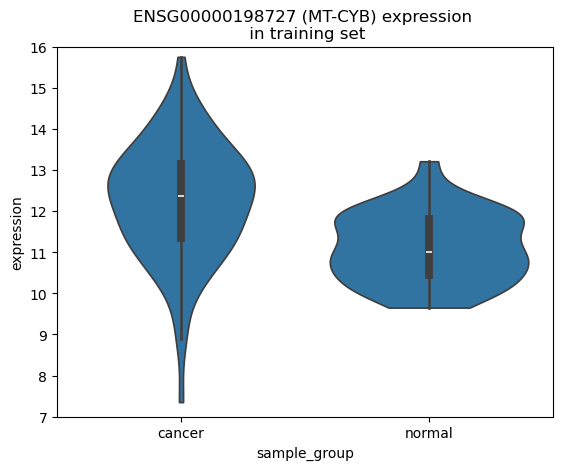

In [61]:
# label 1 is cancer (n = 96)

gene = 'ENSG00000198727'

plot_df = pd.DataFrame({
    'expression': d['X'][gene].values,
    'label': pd.Series(y).map({0: 'normal', 1: 'cancer'})
})

sns.violinplot(data=plot_df, x='label', y='expression', cut = 0)
plt.title(gene + ' (MT-CYB) expression \n in training set')
plt.ylim(7, 16)
plt.xlabel('sample_group')
plt.show()

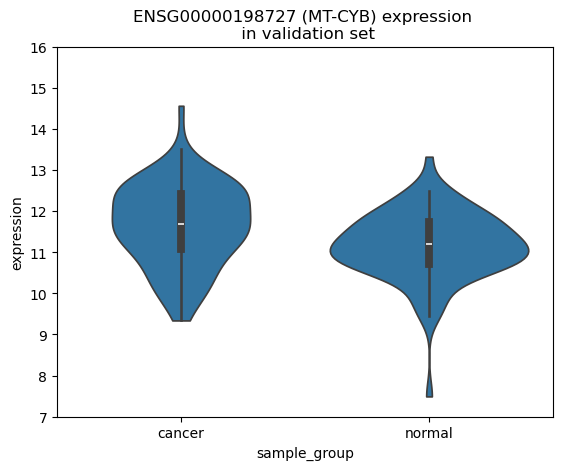

In [63]:
gene = 'ENSG00000198727'

plot_df = pd.DataFrame({
    'expression': val['X'][gene].values,
    'label': pd.Series(val['y_cancer'].values).map({0: 'normal', 1: 'cancer'})
})

sns.violinplot(data=plot_df, x='label', y='expression', cut = 0, order = ['cancer', 'normal'])
plt.ylim(7, 16)
plt.title(gene + ' (MT-CYB) expression \n in validation set')
plt.xlabel('sample_group')
plt.show()